Some Experiment with the Adult Dataset: 
- Not consider Y in the decorellation 
- Consider Y in the decorellation 
- Costum Loss 1 and One Model Per Feature

## Imports

In [1]:
from maxcorr import indicator

from ucimlrepo import fetch_ucirepo 

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import random 

import torch
from torch.utils.data import DataLoader

import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from loss import costum_loss_1, costum_loss_2, costum_loss_3, costum_loss_4
from dataset import AdultDataset, AdultDatasetTarget
from model import DecorellModel, DecorellModelTraining
from metric import FairnessMetric, EqualizedOdds, DemographicParity, HgrMetric

In [2]:
def fix_random(seed: int) -> None:

    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    L.seed_everything(seed, workers=True)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed = 42
fix_random(seed=seed)

Seed set to 42


## Utils 

In [17]:
cfg = {
    'batch_size_train' : 1024,
    'batch_size_test' : 1024,
    'data' : 'experiment',
    'lr' : 1e-4,
    'weight_decay' : 1e-6,
    'alpha' : 1,
    'beta' : 3,
    'epsilon' : 0.05,
    'input_shape' : 7,
    'hidden_shape' : 128,
    'output_shape' : 7,
    'lambda_lr' : 1e-5,
    'theta_lr' : 1e-3,
    'epochs' : 500,
    'method' : 'costum_loss_1'
}

In [4]:
def clean(X,y):
    #Missing Values
    missing_indices = X.dropna().index
    X = X.loc[missing_indices].reset_index(drop=True)
    y = y.loc[missing_indices].reset_index(drop=True)
    #Label Encoding X
    X = X.drop(columns=['fnlwgt', 'capital-gain', 'capital-loss', 'education-num'])
    categorical_cols = X.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
    #One-Hot Encoding y
    one_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    y['income'] = y['income'].astype(str).str.rstrip('.')  
    y = pd.DataFrame(one_encoder.fit_transform(y[['income']]))
    y.columns = one_encoder.get_feature_names_out(['income'])
    y = pd.DataFrame(y['income_>50K'], columns=['income_>50K'])
    return X, y

In [13]:
def prepare_train(cfg):
    model_net = DecorellModel(cfg['input_shape'], cfg['hidden_shape'], cfg['output_shape'])
    if cfg['method'] == 'costum_loss_1':
        model = DecorellModelTraining(model=model_net, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=cfg['epsilon'], costum_loss=costum_loss_1)
    if cfg['method'] == 'costum_loss_2':
        model = DecorellModelTraining(model=model_net, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=cfg['epsilon'], costum_loss=costum_loss_2)
    if cfg['method'] == 'costum_loss_3':
        model = DecorellModelTraining(model=model_net, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=cfg['epsilon'], costum_loss=costum_loss_3)
    if cfg['method'] == 'costum_loss_4':
        model = DecorellModelTraining(model=model_net, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=cfg['epsilon'], costum_loss=costum_loss_4)
    return model

def training_loop(train, cfg, model_train, trainer, dataset_type):
    train_data = dataset_type(train)
    train_loader = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=True)
    print(type(model_train))
    trainer.fit(model=model_train, train_dataloaders=train_loader)


In [27]:
def create_new_data(df_train, df_test, model_train, trainer):
    train_data = AdultDatasetTarget(df_train)
    train_loader = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=False)
    test_data = AdultDatasetTarget(df_test)
    test_loader = DataLoader(test_data, batch_size=cfg['batch_size_test'], shuffle=False)
    x_train_new = trainer.predict(model=model_train, dataloaders=train_loader)
    x_test_new = trainer.predict(model=model_train, dataloaders=test_loader)
    X_train_new, X_test_new = np.array(torch.cat(x_train_new, dim=0)), np.array(torch.cat(x_test_new, dim=0))
    scaler = StandardScaler()
    X_train_new = scaler.fit_transform(X_train_new[:, :-1])
    X_test_new = scaler.transform(X_test_new[:, :-1])
    return X_train_new, X_test_new

def create_old_data(df_train, df_test, colums):
    X_train_old, X_test_old = np.array(df_train[colums]), np.array(df_test[colums])
    scaler = StandardScaler()
    X_train_old = scaler.fit_transform(X_train_old)
    X_test_old = scaler.transform(X_test_old)
    return X_train_old, X_test_old

def create_y(df_train, df_test, target):
    y_train, y_test = np.array(df_train[target]).reshape(-1), np.array(df_test[target]).reshape(-1)
    return y_train, y_test 

def create_y_modified(df_train, df_test, model_train, trainer):
    train_data = AdultDatasetTarget(df_train)
    train_loader = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=False)
    test_data = AdultDatasetTarget(df_test)
    test_loader = DataLoader(test_data, batch_size=cfg['batch_size_test'], shuffle=False)
    x_train_new = trainer.predict(model=model_train, dataloaders=train_loader)
    x_test_new = trainer.predict(model=model_train, dataloaders=test_loader)
    y_train_new, y_test_new = np.array(torch.cat(x_train_new, dim=0)), np.array(torch.cat(x_test_new, dim=0))
    y_train_new, y_test_new = y_train_new[:,-1], y_test_new[:,-1]
    y_train_new = (y_train_new >= 0.5).astype(int)
    y_test_new = (y_test_new >= 0.5).astype(int)
    return y_train_new, y_test_new

In [25]:
def classification(X_train, X_test, y_train, y_test, clf_model, sensitive_attribute):
    
    clf = clf_model
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    aupr = average_precision_score(y_test, y_prob[:,1])

    equalized_odds = EqualizedOdds(sensitive_attribute=sensitive_attribute)
    demographic_parity = DemographicParity(sensitive_attribute=sensitive_attribute)
    hgr_metric = HgrMetric(sensitive_attribute=sensitive_attribute)
    
    eo = equalized_odds(y_test, y_pred)
    dp = demographic_parity(y_test, y_pred)
    hgr = hgr_metric(y_test, y_pred)
    
    return accuracy, aupr, hgr, eo, dp

In [8]:
def evaluate_clf(clf_dictionary, df_train, df_test, model_train, trainer):
    X_train_old, X_test_old = create_old_data(df_train, df_test, ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'hours-per-week'] )
    y_train_old, y_test_old = create_y(df_train, df_test, 'income_>50K')
    X_train_new, X_test_new = create_new_data(df_train, df_test, model_train, trainer)
    y_train_new, y_test_new = create_y_modified(df_train, df_test, model_train, trainer)
    
    accuracy = {}
    AUPR = {}
    HGR = {}
    EO = {}
    DP = {}
    
    for key, values in clf_dictionary.items():
        accuracy_new, aupr_new, fairness_new, equalized_odd_new, dem_parity_new = classification(X_train_new, X_test_new, y_train_new, y_test_new, values, np.array(df_test['sex']))
        accuracy_old, aupr_old, fairness_old, equalize_odd_old, dem_parity_old  = classification(X_train_old, X_test_old, y_train_old, y_test_old, values, np.array(df_test['sex']))
        print('Model: ', key)
        print(f'Accuracy_new: {accuracy_new:.4f}, AUPRC_new: {aupr_new:.4f}, HGR_new: {fairness_new:.4f}, Equalized Odds: {equalized_odd_new:.4f}, Demographic Parity: {dem_parity_new:.4f}')
        print(f'Accuracy_old: {accuracy_old:.4f}, AUPRC_old: {aupr_old:.4f}, HGR_old: {fairness_old:.4f}, Equalized Odds: {equalize_odd_old:.4f}, Demographic Parity: {dem_parity_old:.4f}')
        
        accuracy[key] = accuracy_new
        AUPR[key] = aupr_new
        HGR[key] = fairness_new
        EO[key] = equalized_odd_new
        DP[key] = dem_parity_new
    print('\n')
    
    return accuracy, AUPR, HGR, EO, DP

In [9]:
## Loading And Cleanining Data
adult = fetch_ucirepo(id=2) 
  
X = adult.data.features 
y = adult.data.targets

X_clean, y_clean = clean(X,y)
df_clean = pd.concat([X_clean, y_clean], axis=1)

df_train, df_test = train_test_split(df_clean, test_size=0.2, random_state=seed, stratify=df_clean['income_>50K'])

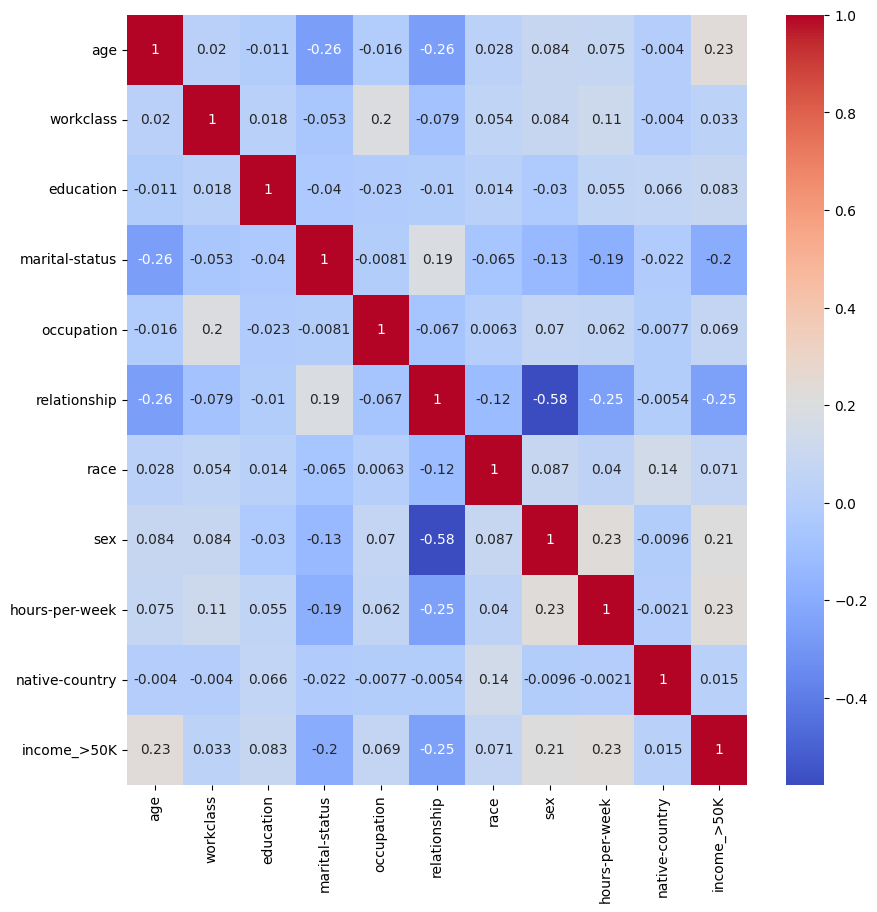

In [10]:
## Correltion map
corr = df_train.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Training considering all features in one-model and not considering y

In [8]:
early_stopping = EarlyStopping(monitor='lagrangian_loss', mode='min', patience=15,verbose=True)
model_checkpoint = ModelCheckpoint(dirpath="checkpoints/", filename="best_model_adult_data_1", monitor="lagrangian_loss", mode="min", save_top_k=1)

model_train = prepare_train(cfg)
logger = TensorBoardLogger("lightning_logs", name='AdultData1')
trainer = L.Trainer(callbacks=[early_stopping, model_checkpoint], max_epochs=cfg['epochs'], logger=logger, deterministic=True, benchmark=False)
training_loop(df_train, cfg, model_train, trainer, AdultDataset)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\claud\Desktop\Intelligenza artificiale\Progetti\Privacy-Fairness\.venv\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


<class 'model.DecorellModelTraining'>


c:\Users\claud\Desktop\Intelligenza artificiale\Progetti\Privacy-Fairness\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\claud\Desktop\Intelligenza artificiale\Progetti\Privacy-Fairness\checkpoints exists and is not empty.

  | Name  | Type          | Params | Mode 
------------------------------------------------
0 | model | DecorellModel | 17.7 K | train
------------------------------------------------
17.7 K    Trainable params
0         Non-trainable params
17.7 K    Total params
0.071     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
c:\Users\claud\Desktop\Intelligenza artificiale\Progetti\Privacy-Fairness\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to i

Epoch 0: 100%|██████████| 38/38 [00:05<00:00,  6.95it/s, v_num=0, lagrangian_loss=0.727, constraint=0.0349]

Metric lagrangian_loss improved. New best score: 0.727


...

Epoch 105: 100%|██████████| 38/38 [00:06<00:00,  6.19it/s, v_num=0, lagrangian_loss=0.0763, constraint=0.00292]

Metric lagrangian_loss improved by 0.003 >= min_delta = 0.0. New best score: 0.076


Epoch 120: 100%|██████████| 38/38 [00:06<00:00,  6.30it/s, v_num=0, lagrangian_loss=0.0854, constraint=0.00591]

Monitored metric lagrangian_loss did not improve in the last 15 records. Best score: 0.076. Signaling Trainer to stop.


Epoch 120: 100%|██████████| 38/38 [00:06<00:00,  6.30it/s, v_num=0, lagrangian_loss=0.0854, constraint=0.00591]


In [21]:
model = DecorellModel(cfg['input_shape'], cfg['hidden_shape'], cfg['output_shape'])
model_train = DecorellModelTraining.load_from_checkpoint('checkpoints/best_model_adult_data_1.ckpt', model=model, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=0.05, costum_loss=costum_loss_1)

In [23]:
#Data preparation
train_data = AdultDataset(df_train)
train_loader = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=False)
test_data = AdultDataset(df_test)
test_loader = DataLoader(test_data, batch_size=cfg['batch_size_test'], shuffle=False)
x_train_new = trainer.predict(model_train, dataloaders=train_loader)
x_test_new = trainer.predict(model=model_train, dataloaders=test_loader)
x_train_new = torch.cat(x_train_new, dim=0)
x_test_new = torch.cat(x_test_new, dim=0)
#Check features per features
ind = indicator(semantics='hgr', algorithm='dk', backend='torch')
features = ['Workclass', 'Education', 'Marital Status', 'Occupation', 'Relationship', 'Hours per week']
new_correlation = []
original_correlation = []
for i in range(6):
    new_correlation.append(ind.compute(x_test_new[:, i], test_data.z))
    original_correlation.append(ind.compute(test_data.x[:, i], test_data.z))
    print(f'{features[i]} attribute: new correlation: {new_correlation[i]:.4f}, original correlation: {original_correlation[i]:.4f}')

print('\n')
print(f'Mean results: new_correlation {np.mean(new_correlation):.4f}, original_correlation {np.mean(original_correlation):.4f}')


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 57.31it/s]
Workclass attribute: new correlation: 0.0172, original correlation: 0.1034
Education attribute: new correlation: 0.0211, original correlation: 0.0286
Marital Status attribute: new correlation: 0.0291, original correlation: 0.4520
Occupation attribute: new correlation: 0.0260, original correlation: 0.3070
Relationship attribute: new correlation: 0.0564, original correlation: 0.6400
Hours per week attribute: new correlation: 0.0282, original correlation: 0.2593


Mean results: new_correlation 0.0296, original_correlation 0.2984


In [22]:
import warnings
warnings.filterwarnings("ignore")

clf_tree = DecisionTreeClassifier(random_state=seed)
clf_log = LogisticRegression(random_state=seed)
clf_forest  = RandomForestClassifier(random_state=seed)
clf_boost = AdaBoostClassifier(random_state=seed)
clf_neural = MLPClassifier(random_state=seed)
clf_dictionary = {'DecisionTree': clf_tree, 'LogisticRegression': clf_log, 'RandomForest': clf_forest, 'AdaBoost': clf_boost, 'NeuralNetwork': clf_neural}
accuracy, AUPR, HGR, EO, DP = evaluate_clf(clf_dictionary, df_train, df_test, model_train, trainer)


Predicting DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 56.67it/s]
Model:  DecisionTree
Accuracy_new: 0.8128, AUPRC_new: 0.5262, HGR_new: 0.1926, Equalized Odds: 0.1243, Demographic Parity: 0.1642
Accuracy_old: 0.8140, AUPRC_old: 0.5389, HGR_old: 0.1952, Equalized Odds: 0.1046, Demographic Parity: 0.1673
Model:  LogisticRegression
Accuracy_new: 0.7518, AUPRC_new: 0.3496, HGR_new: 0.1350, Equalized Odds: 0.1990, Demographic Parity: 0.0461
Accuracy_old: 0.7539, AUPRC_old: 0.4271, HGR_old: 0.1341, Equalized Odds: 0.0911, Demographic Parity: 0.0615
Model:  RandomForest
Accuracy_new: 0.8203, AUPRC_new: 0.6439, HGR_new: 0.2101, Equalized Odds: 0.1404, Demographic Parity: 0.1775
Accuracy_old: 0.8226, AUPRC_old: 0.6471, HGR_old: 0.2017, Equalized Odds: 0.1125, Demographic Parity: 0.1725
Model:  AdaBoost
Accuracy_new: 0.8091, AUPRC_new: 0.6041, HGR_new: 0.1837, Equalized Odds: 0.1323, Demographic Parity: 0.1445
Accuracy_old: 0.8259, AUPRC_old: 0.6748, HGR_old: 0.2541, Equalized Odds: 0.27

Training considering y

In [19]:
early_stopping = EarlyStopping(monitor='lagrangian_loss', mode='min', patience=15,verbose=True)
model_checkpoint = ModelCheckpoint(dirpath="checkpoints/", filename="best_model_adult_data_2", monitor="lagrangian_loss", mode="min", save_top_k=1)

model_train = prepare_train(cfg)
logger = TensorBoardLogger("lightning_logs", name='AdultData2')
trainer = L.Trainer(callbacks=[early_stopping, model_checkpoint], max_epochs=cfg['epochs'], logger=logger, deterministic=True, benchmark=False)
training_loop(df_train, cfg, model_train, trainer, AdultDatasetTarget)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\claud\Desktop\Intelligenza artificiale\Progetti\Privacy-Fairness\.venv\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
c:\Users\claud\Desktop\Intelligenza artificiale\Progetti\Privacy-Fairness\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:654: Checkpoint directory C:\Users\claud\Desktop\Intelligenza artificiale\Progetti\Privacy-Fairness\checkpoints exists and is not empty.

  | Name  | Type          | Params | Mode 
------------------------------------------------
0 | model | DecorellModel | 17.8 K | train
------------------------------------------------
17.8 K    Trainable params
0         Non-trainable params
17.8 K    Total params
0.071     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in ev

<class 'model.DecorellModelTraining'>
Epoch 0: 100%|██████████| 38/38 [00:05<00:00,  6.67it/s, v_num=2, lagrangian_loss=0.724, constraint=0.0388]

Metric lagrangian_loss improved. New best score: 0.724


Epoch 1: 100%|██████████| 38/38 [00:06<00:00,  6.28it/s, v_num=2, lagrangian_loss=0.475, constraint=0.0138]

Metric lagrangian_loss improved by 0.250 >= min_delta = 0.0. New best score: 0.475


...

Epoch 129: 100%|██████████| 38/38 [00:10<00:00,  3.76it/s, v_num=2, lagrangian_loss=0.076, constraint=0.00278] 

Metric lagrangian_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.076


Epoch 144: 100%|██████████| 38/38 [00:09<00:00,  3.86it/s, v_num=2, lagrangian_loss=0.0776, constraint=0.00331]

Monitored metric lagrangian_loss did not improve in the last 15 records. Best score: 0.076. Signaling Trainer to stop.


Epoch 144: 100%|██████████| 38/38 [00:09<00:00,  3.85it/s, v_num=2, lagrangian_loss=0.0776, constraint=0.00331]


In [ ]:
model = DecorellModel(cfg['input_shape'], cfg['hidden_shape'], cfg['output_shape'])
model_train = DecorellModelTraining.load_from_checkpoint('checkpoints/best_model_adult_data_2.ckpt', model=model, lr=cfg['lr'], weight_decay=cfg['weight_decay'], alpha=cfg['alpha'], beta=cfg['beta'], epsilon=0.05, costum_loss=costum_loss_1)

In [21]:
#Data preparation
train_data = AdultDatasetTarget(df_train)
train_loader = DataLoader(train_data, batch_size=cfg['batch_size_train'], shuffle=False)
test_data = AdultDatasetTarget(df_test)
test_loader = DataLoader(test_data, batch_size=cfg['batch_size_test'], shuffle=False)
x_train_new = trainer.predict(model_train, dataloaders=train_loader)
x_test_new = trainer.predict(model=model_train, dataloaders=test_loader)
x_train_new = torch.cat(x_train_new, dim=0)
x_test_new = torch.cat(x_test_new, dim=0)
#Check features per features
ind = indicator(semantics='hgr', algorithm='dk', backend='torch')
features = ['Workclass', 'Education', 'Marital Status', 'Occupation', 'Relationship', 'Hours per week', 'Income']
new_correlation = []
original_correlation = []
for i in range(7):
    new_correlation.append(ind.compute(x_test_new[:, i], test_data.z))
    original_correlation.append(ind.compute(test_data.x[:, i], test_data.z))
    print(f'{features[i]} attribute: new correlation: {new_correlation[i]:.4f}, original correlation: {original_correlation[i]:.4f}')

print('\n')
print(f'Mean results: new_correlation {np.mean(new_correlation):.4f}, original_correlation {np.mean(original_correlation):.4f}')


c:\Users\claud\Desktop\Intelligenza artificiale\Progetti\Privacy-Fairness\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

Epoch 0:   0%|          | 0/38 [27:52<?, ?it/s]12it/s]
Predicting: |          | 38/? [00:01<00:00, 34.70it/s]
Predicting DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 48.57it/s]
Workclass attribute: new correlation: 0.0159, original correlation: 0.1034
Education attribute: new correlation: 0.0202, original correlation: 0.0286
Marital Status attribute: new correlation: 0.0239, original correlation: 0.4520
Occupation attribute: new correlation: 0.0098, original correlation: 0.3070
Relationship attribute: new correlation: 0.0221, original correlation: 0.6400
Hours per week attribute: new correlation: 0.0193, original correlation: 0.2593
Income attribute: new correlation: 0.0416, original correlation: 0.2174


Mean results: new_correlation 0.0218, original_correlation 0.2868


In [28]:
import warnings
warnings.filterwarnings("ignore")

clf_tree = DecisionTreeClassifier(random_state=seed)
clf_log = LogisticRegression(random_state=seed)
clf_forest  = RandomForestClassifier(random_state=seed)
clf_boost = AdaBoostClassifier(random_state=seed)
clf_neural = MLPClassifier(random_state=seed)
clf_dictionary = {'DecisionTree': clf_tree, 'LogisticRegression': clf_log, 'RandomForest': clf_forest, 'AdaBoost': clf_boost, 'NeuralNetwork': clf_neural}
accuracy, AUPR, HGR, EO, DP = evaluate_clf(clf_dictionary, df_train, df_test, model_train, trainer)

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting DataLoader 0: 100%|██████████| 10/10 [00:00<00:00, 23.57it/s]
Model:  DecisionTree
Accuracy_new: 0.9769, AUPRC_new: 0.7638, HGR_new: 0.0505, Equalized Odds: 0.0553, Demographic Parity: 0.0305
Accuracy_old: 0.8140, AUPRC_old: 0.5389, HGR_old: 0.1952, Equalized Odds: 0.1046, Demographic Parity: 0.1673
Model:  LogisticRegression
Accuracy_new: 0.9141, AUPRC_new: 0.2576, HGR_new: 0.0119, Equalized Odds: 0.0054, Demographic Parity: 0.0018
Accuracy_old: 0.7539, AUPRC_old: 0.4271, HGR_old: 0.1341, Equalized Odds: 0.0911, Demographic Parity: 0.0615
Model:  RandomForest
Accuracy_new: 0.9849, AUPRC_new: 0.9722, HGR_new: 0.0544, Equalized Odds: 0.0739, Demographic Parity: 0.0308
Accuracy_old: 0.8226, AUPRC_old: 0.6471, HGR_old: 0.2017, Equalized Odds: 0.1125, Demographic Parity: 0.1725
Model:  AdaBoost
Accuracy_new: 0.9156, AUPRC_new: 0.3674, HGR_new: 0.0012, Equalized Odds: 0.1159, Demographic Parity: 0.0004
Accuracy_old: 0.8259, AUPRC_old: 0.6748, HGR_old: 0.2541, Equalized Odds: 0.27